In [1]:
import ants
import numpy as np
import os
import scipy.io

In [2]:
def get_mat(_path):
    data = scipy.io.loadmat(_path) # 读取mat文件
    for key in data.keys():
        if ("__" not in key):
            _key = key
    #print(_path)
    #print(data[_key].shape)
    output = data[_key]
    return(output)

In [15]:
for _mode in ["train","test"]:
    for _type in ["inp","out"]:

        files = [os.path.join(f"/home/iint/tf/0407/boron3D/{_mode}/{_type}/",_file) for _file in os.listdir(f"/home/iint/tf/0407/boron3D/{_mode}/{_type}") if ".mat" in _file]
        #print(files)
        for file in files:
            array = get_mat(file)
            if _type == "inp":
                assert array.shape == (2, 125, 125, 60)#,print(array.shape)
            else:
                assert array.shape == (1, 125, 125, 60)
            img = ants.from_numpy(array.transpose(0,3,1,2))
            img.set_spacing((1,3,2.5391,2.5391))
            print(file.split('.')[0]+".nii")
            ants.image_write(img,(file.split('.')[0]+".nii").replace("phantom", "patient100"))

/home/iint/tf/0407/boron3D/train/inp/patient27.nii
/home/iint/tf/0407/boron3D/train/inp/patient41.nii
/home/iint/tf/0407/boron3D/train/inp/patient26.nii
/home/iint/tf/0407/boron3D/train/inp/patient54.nii
/home/iint/tf/0407/boron3D/train/inp/patient55.nii
/home/iint/tf/0407/boron3D/train/inp/patient11.nii
/home/iint/tf/0407/boron3D/train/inp/patient14.nii
/home/iint/tf/0407/boron3D/train/inp/patient24.nii
/home/iint/tf/0407/boron3D/train/inp/patient6.nii
/home/iint/tf/0407/boron3D/train/inp/phantom30.nii
/home/iint/tf/0407/boron3D/train/inp/patient40.nii
/home/iint/tf/0407/boron3D/train/inp/phantom23.nii
/home/iint/tf/0407/boron3D/train/inp/patient22.nii
/home/iint/tf/0407/boron3D/train/inp/patient32.nii
/home/iint/tf/0407/boron3D/train/inp/patient42.nii
/home/iint/tf/0407/boron3D/train/inp/patient38.nii
/home/iint/tf/0407/boron3D/train/inp/phantom1.nii
/home/iint/tf/0407/boron3D/train/inp/patient43.nii
/home/iint/tf/0407/boron3D/train/inp/patient33.nii
/home/iint/tf/0407/boron3D/train/

In [11]:
import monai
import torch.nn as nn
import os
import matplotlib.pyplot as plt
import numpy as np
import shutil
import tempfile
import torch
from torch.nn import MSELoss
from monai.apps import download_url, download_and_extract
from monai.config import print_config
from monai.data import DataLoader, Dataset, CacheDataset
from monai.losses import BendingEnergyLoss, MultiScaleLoss, DiceLoss
from monai.metrics import DiceMetric
from monai.networks.blocks import Warp
from monai.networks.nets import LocalNet
from monai.transforms import (
    AddChanneld,
    Compose,
    LoadImaged,
    RandAffined,
    Resized,
    ScaleIntensityRanged,
    EnsureTyped,
)
from monai.utils import set_determinism, first

torch.multiprocessing.set_sharing_strategy('file_system')
print_config()


input_data_dir = "/home/iint/tf/0407/boron3D/train/inp"
output_data_dir = "/home/iint/tf/0407/boron3D/train/out"
test_input_data_dir = "/home/iint/tf/0407/boron3D/test/inp"
test_output_data_dir = "/home/iint/tf/0407/boron3D/test/out"

data_dicts = [
    {
        "input": os.path.join(input_data_dir,
                                    f"patient{idx}.nii"),
        "output": os.path.join(output_data_dir,
                                    f"patient{idx}.nii"),
        "pname" : f"patient{idx}.nii"
    }
    for idx in set([_file.split(".")[0].split("patient")[1] for _file in os.listdir(input_data_dir) if "patient" in _file])
]
test_data_dicts = [
    {
        "input": os.path.join(test_input_data_dir,
                                    f"patient{idx}.nii"),
        "output": os.path.join(test_output_data_dir,
                                    f"patient{idx}.nii"),
        "pname" : f"patient{idx}.nii"
    }
    for idx in set([_file.split(".")[0].split("patient")[1] for _file in os.listdir(test_input_data_dir) if "patient" in _file])
]


MONAI version: 0.9.dev2212
Numpy version: 1.22.2
Pytorch version: 1.10.0+cu102
MONAI flags: HAS_EXT = False, USE_COMPILED = False
MONAI rev id: d93c76c6287099673b45957661232f054e558ca1
MONAI __file__: /opt/anaconda3/lib/python3.8/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.8
Nibabel version: 3.2.1
scikit-image version: 0.17.2
Pillow version: 8.0.1
Tensorboard version: 2.8.0
gdown version: 4.4.0
TorchVision version: 0.8.2
tqdm version: 4.50.2
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.7.2
pandas version: 1.1.3
einops version: 0.3.2
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#installing-the-recommended-dependencies



In [12]:
len(data_dicts)

52

In [13]:
len(test_data_dicts)

4

In [14]:

train_files, val_files = data_dicts, test_data_dicts

set_determinism(seed=0)


train_transforms = Compose(
    [
        LoadImaged(
            keys=["input", "output"]
        ),

        #ScaleIntensityRanged(
        #    keys=["input", "output"]
        #    a_min=-1000, a_max=2000, b_min=0.0, b_max=1.0, clip=True,
        #),
        RandAffined(
            keys=["input", "output"],
            mode=('bilinear', 'bilinear'),
            prob=1.0, spatial_size=(256, 256, 64),
            rotate_range=(0, 0, np.pi / 15), scale_range=(0.1, 0.1, 0.1)
        ),
        Resized(
            keys=["input", "output"],
            mode=('trilinear', 'trilinear'),
            align_corners=(True, True),
            spatial_size=(128,128,64)
        ),
        EnsureTyped(
            keys=["input", "output"]
        ),
    ]
)
val_transforms = Compose(
    [
        LoadImaged(
            keys=["input", "output"]
        ),

        #ScaleIntensityRanged(
        #    keys=["input", "output"]
        #    a_min=-1000, a_max=2000, b_min=0.0, b_max=1.0, clip=True,
        #),
        #RandAffined(
        #    keys=["input", "output"],
        #    mode=('bilinear', 'bilinear'),
        #    prob=1.0, spatial_size=(256, 256, 64),
        #    rotate_range=(0, 0, np.pi / 15), scale_range=(0.1, 0.1, 0.1)
        #),
        Resized(
            keys=["input", "output"],
            mode=('trilinear', 'trilinear'),
            align_corners=(True, True),
            spatial_size=(128,128,64)
        ),
        EnsureTyped(
            keys=["input", "output"]
        ),
    ]
)


train_ds = CacheDataset(data=train_files, transform=train_transforms,
                        cache_rate=1.0, num_workers=20)
train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=20)
val_ds = CacheDataset(data=val_files, transform=val_transforms,
                      cache_rate=1.0, num_workers=20)

val_loader = DataLoader(val_ds, batch_size=1, num_workers=20)
os.environ["CUDA_VISIBLE_DEVICES"] = '0,1'


Loading dataset: 100%|██████████| 4/4 [00:00<00:00, 14.15it/s]


In [31]:
next(val_loader)

TypeError: 'DataLoader' object is not an iterator

In [34]:
device = torch.device("cuda")


net = monai.networks.nets.BasicUNet(spatial_dims=3, in_channels=3, out_channels=1, features=(32, 32, 64, 128, 256, 32), act=('LeakyReLU', {'negative_slope': 0.1, 'inplace': True}), norm=('BATCH', {'affine': True}), bias=True, dropout=0.0, upsample='deconv', dimensions=None)

image_loss = MSELoss()
optimizer = torch.optim.Adam(net.parameters(), 1e-5)
net = net.to(device)
net = nn.DataParallel(net, device_ids = [0,1])

max_epochs = 500
val_interval = 1
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []

for epoch in range(max_epochs):
    print(f"epoch {epoch + 1}/{max_epochs}")
    net.train()
    epoch_loss = 0
    step = 0
    for batch_data in train_loader:
        #print(batch_data)
        print(batch_data["pname"][0])
        step += 1
        optimizer.zero_grad()
        _input = batch_data["input"].to(device)
        pre_img= net(_input)

        #plt.imshow(pre_img.cpu().detach().numpy()[0, 0].transpose((1, 0, 2))[:, :, 30], cmap="gray")
        #plt.show()
        _output = batch_data["output"].to(device)
        loss = image_loss(pre_img, _output)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")
    if epoch%20 == 0:
        torch.save(net.module.state_dict(), f"./{epoch}.ckpt")


BasicUNet features: (32, 32, 64, 128, 256, 32).
epoch 1/500
['patient30.nii']
['patient14.nii']
['patient15.nii']
['patient2.nii']
['patient4.nii']
['patient52.nii']
['patient33.nii']


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ff516fb1b80>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1328, in __del__
    self._shutdown_workers()
  File "/opt/anaconda3/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1301, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/opt/anaconda3/lib/python3.8/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
  File "/opt/anaconda3/lib/python3.8/multiprocessing/popen_fork.py", line 44, in wait
    if not wait([self.sentinel], timeout):
  File "/opt/anaconda3/lib/python3.8/multiprocessing/connection.py", line 931, in wait
    ready = selector.select(timeout)
  File "/opt/anaconda3/lib/python3.8/selectors.py", line 415, in select
    fd_event_list = self._selector.poll(timeout)
KeyboardInterrupt: 


KeyboardInterrupt: 

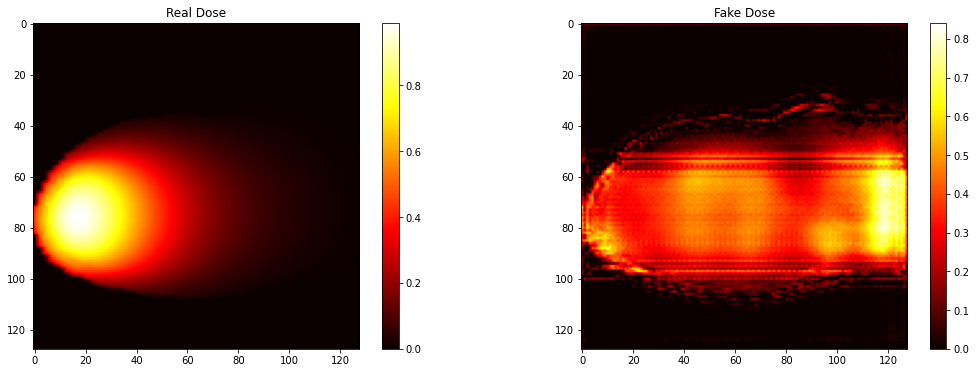

In [38]:
epoch = "109"
root = "/home/iint/tf/3ddose/npy/"
def normnpy(npy):
    npy[npy<0]=0
    npy[npy>1]=1
    return (npy-npy.min())/(npy.max()-npy.min())
real_dose = normnpy(np.load(os.path.join(root,f"{epoch}patient47.nii_real_dose.npy")))
fake_dose = normnpy(np.load(os.path.join(root,f"{epoch}patient47.nii_fake_dose.npy")))

plt.figure(figsize=(18,6))
plt.subplot(1,2,1)
plt.imshow(real_dose[:,:,30],"hot")
plt.colorbar()
plt.title("Real Dose")
plt.subplot(1,2,2)
plt.imshow(fake_dose[:,:,30],"hot")
plt.colorbar()
plt.title("Fake Dose")
plt.show()

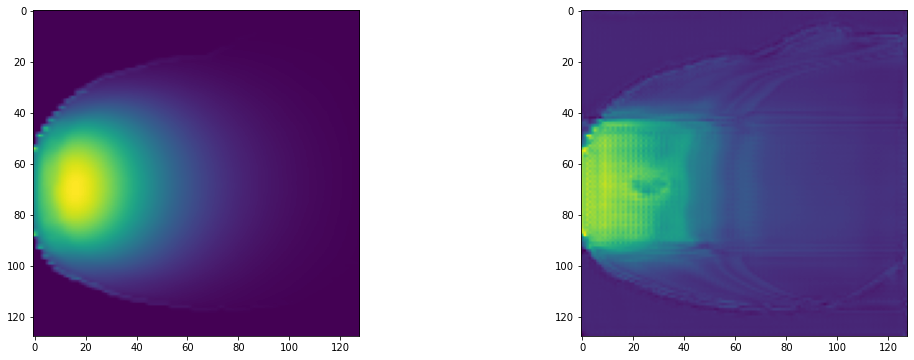

In [62]:
epoch = "349"
root = "/home/iint/tf/3ddose/npy/"

real_dose = np.load(os.path.join(root,f"{epoch}patient55.nii_real_dose.npy"))
fake_dose = np.load(os.path.join(root,f"{epoch}patient55.nii_fake_dose.npy"))

plt.figure(figsize=(18,6))
plt.subplot(1,2,1)
plt.imshow(real_dose[:,:,30])
plt.subplot(1,2,2)
plt.imshow(fake_dose[:,:,30])
plt.show()